In [76]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
%matplotlib inline

In [77]:
transform = transforms.ToTensor()

In [78]:
train_data = datasets.MNIST(root='Data', train = True, download = True, transform = transform)

In [79]:
test_data = datasets.MNIST(root='Data', train = False, download = True, transform = transform)

In [80]:
train_data

Dataset MNIST
    Number of datapoints: 60000
    Root location: Data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [81]:
test_data

Dataset MNIST
    Number of datapoints: 10000
    Root location: Data
    Split: Test
    StandardTransform
Transform: ToTensor()

In [82]:
train_loader = DataLoader(train_data, batch_size = 10, shuffle = True)
test_loader = DataLoader(test_data, batch_size = 10, shuffle = False)

## Defining Convolutional Model

In [83]:
# 1 - single color channel (Gray), 6 feature maps/filters, 3 - kernel size (3x3), 1 - stride
conv1 = nn.Conv2d(1,6,3,1)      # conv1 --> 6 filters --> pooling --> conv2

# 6 Input Filters from conv1, 16 filters, 3 - kernel size (3x3), 1 - stride
conv2 = nn.Conv2d(6,16,3,1) 

6 filters will be generated by 6 different kernels

In [84]:
for i, (X_train, y_train) in enumerate(train_data):
    break

In [85]:
X_train.shape

torch.Size([1, 28, 28])

In the above cells just to get an idea we break the **for** loop in 1st iteration ensures that only single image data is stored in X_train and y_train. And the shape of X_train basically define (No of color channel, width, height).As we have gray images, No of color channel = 1. But, issue is that once we start dealing with the batches we also have to store the image number in the shape. This can be done by converting the 3D tensor into 4D, where 1st element will be image number.

In [86]:
x = X_train.view(1,1,28,28)
x = F.relu(conv1(x))

In [87]:
x.shape

torch.Size([1, 6, 26, 26])

After passing from 1st convolution layer, we pass the output feature map to pooling layer. 

In [88]:
# Run the first pooling layer
x = F.max_pool2d(x, 2, 2)
print(x.shape)

torch.Size([1, 6, 13, 13])


In [89]:
# Perform the second convolution/activation
x = F.relu(conv2(x))
print(x.shape)

torch.Size([1, 16, 11, 11])


In [90]:
# Run the second pooling layer
x = F.max_pool2d(x, 2, 2)
print(x.shape)

torch.Size([1, 16, 5, 5])


Here 16 is number of output pooled maps of 5x5 matrices. Now, we have the output from last layer which can be fed to fully connected layer (ANN) to get the output. But, only issue is that the shape of x is not suitable for ANN. Therefore, to make it suitable we have to flatten the data. So, by converting all those data in an single array we can have 16x5x5 = 400 elements for 1 image.

In [91]:
# Flatten the data
x = x.view(-1, 5*5*16)
print(x.shape)

torch.Size([1, 400])


Therefore, when we will run the batch it will be of size [10,400], as our batch size is 10.

## Now, Let's create our model

In [92]:
class ConvolutionalNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 6, 3, 1)
        self.conv2 = nn.Conv2d(6, 16, 3, 1)
        self.fc1 = nn.Linear(5*5*16, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84,10)

    def forward(self, X):
        X = F.relu(self.conv1(X))
        X = F.max_pool2d(X, 2, 2)
        X = F.relu(self.conv2(X))
        X = F.max_pool2d(X, 2, 2)
        X = X.view(-1, 5*5*16)
        X = F.relu(self.fc1(X))
        X = F.relu(self.fc2(X))
        X = self.fc3(X)
        return F.log_softmax(X, dim=1)

In [93]:
torch.manual_seed(42)
model = ConvolutionalNetwork()
model

ConvolutionalNetwork(
  (conv1): Conv2d(1, 6, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

In [94]:
def count_parameters(model):
    params = [p.numel() for p in model.parameters() if p.requires_grad]
    for item in params:
        print(f'{item:>6}')
    print(f'______\n{sum(params):>6}')

In [95]:
count_parameters(model)

    54
     6
   864
    16
 48000
   120
 10080
    84
   840
    10
______
 60074


- Including the bias terms for each layer, the total number of parameters being trained is:<br>

$\quad\begin{split}(1\times6\times3\times3)+6+(6\times16\times3\times3)+16+(400\times120)+120+(120\times84)+84+(84\times10)+10 &=\\
54+6+864+16+48000+120+10080+84+840+10 &= 60,074\end{split}$<br>

In [96]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [97]:
import time
start_time = time.time()

epochs = 5
train_losses = []
test_losses = []
train_correct = []
test_correct = []

for i in range(epochs):
    trn_corr = 0
    tst_corr = 0
    
    # Run the training batches
    for b, (X_train, y_train) in enumerate(train_loader):
        b+=1
        
        # Apply the model
        y_pred = model(X_train)  # we don't flatten X-train here
        loss = criterion(y_pred, y_train)
 
        # Tally the number of correct predictions
        predicted = torch.max(y_pred.data, 1)[1]
        batch_corr = (predicted == y_train).sum()
        trn_corr += batch_corr
        
        # Update parameters
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Print interim results
        if b%600 == 0:
            print(f'epoch: {i:2}  batch: {b:4} [{10*b:6}/60000]  loss: {loss.item():10.8f}  \
accuracy: {trn_corr.item()*100/(10*b):7.3f}%')
        
    train_losses.append(loss)
    train_correct.append(trn_corr)
        
    # Run the testing batches
    with torch.no_grad():
        for b, (X_test, y_test) in enumerate(test_loader):

            # Apply the model
            y_val = model(X_test)

            # Tally the number of correct predictions
            predicted = torch.max(y_val.data, 1)[1] 
            tst_corr += (predicted == y_test).sum()
            
    loss = criterion(y_val, y_test)
    test_losses.append(loss)
    test_correct.append(tst_corr)


current_time = time.time()
total = current_time - start_time
print(f'total time taken : {total}')

epoch:  0  batch:  600 [  6000/60000]  loss: 0.04255065  accuracy:  78.483%
epoch:  0  batch: 1200 [ 12000/60000]  loss: 0.08127408  accuracy:  85.825%
epoch:  0  batch: 1800 [ 18000/60000]  loss: 0.31574422  accuracy:  88.689%
epoch:  0  batch: 2400 [ 24000/60000]  loss: 0.02466616  accuracy:  90.479%
epoch:  0  batch: 3000 [ 30000/60000]  loss: 0.00670763  accuracy:  91.617%
epoch:  0  batch: 3600 [ 36000/60000]  loss: 0.00124135  accuracy:  92.472%
epoch:  0  batch: 4200 [ 42000/60000]  loss: 0.46397892  accuracy:  93.110%
epoch:  0  batch: 4800 [ 48000/60000]  loss: 0.03001723  accuracy:  93.562%
epoch:  0  batch: 5400 [ 54000/60000]  loss: 0.00727256  accuracy:  94.006%
epoch:  0  batch: 6000 [ 60000/60000]  loss: 0.04708690  accuracy:  94.303%
epoch:  1  batch:  600 [  6000/60000]  loss: 0.07831076  accuracy:  97.700%
epoch:  1  batch: 1200 [ 12000/60000]  loss: 0.05106743  accuracy:  97.850%
epoch:  1  batch: 1800 [ 18000/60000]  loss: 0.00332345  accuracy:  97.900%
epoch:  1  b

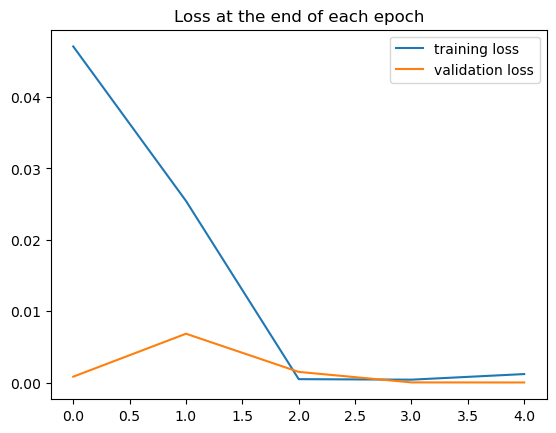

In [98]:
plt.plot([train_losses[i].detach().numpy() for i in range(len(train_losses))], label='training loss')
plt.plot([test_losses[i].detach().numpy() for i in range(len(test_losses))], label='validation loss')
plt.title('Loss at the end of each epoch')
plt.legend();

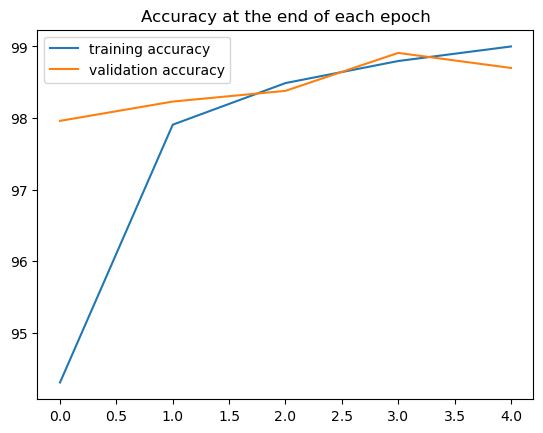

In [100]:
plt.plot([t/600 for t in train_correct], label='training accuracy')
plt.plot([t/100 for t in test_correct], label='validation accuracy')
plt.title('Accuracy at the end of each epoch')
plt.legend();

## Evaluate Test Data

In [101]:
test_load_all = DataLoader(test_data, batch_size = 10000, shuffle = False)

In [102]:
with torch.no_grad():
    correct = 0
    for X_test, y_test in test_load_all:
        y_val = model(X_test)
        predicted = torch.max(y_val,1)[1]
        correct += (predicted == y_test).sum()

In [103]:
accuracy_all = correct.item()/len(test_data)

In [104]:
print(accuracy_all)

0.987


In [105]:
# print a row of values for reference
np.set_printoptions(formatter=dict(int=lambda x: f'{x:4}'))
print(np.arange(10).reshape(1,10))
print()

# print the confusion matrix
print(confusion_matrix(predicted.view(-1), y_test.view(-1)))

[[   0    1    2    3    4    5    6    7    8    9]]

[[ 977    0    2    0    0    2    6    0    6    1]
 [   0 1134    3    0    0    0    2    5    1    0]
 [   2    0 1024    4    0    0    1    3    4    0]
 [   0    0    0  996    0    7    0    0    2    0]
 [   0    0    1    0  980    0    1    1    3   19]
 [   0    0    0    5    0  872    3    0    0    4]
 [   0    1    0    0    0    5  944    0    2    0]
 [   1    0    2    4    0    1    0 1015    2    5]
 [   0    0    0    1    0    0    1    1  950    2]
 [   0    0    0    0    2    5    0    3    4  978]]


## Examine the misses
We can track the index positions of "missed" predictions, and extract the corresponding image and label. We'll do this in batches to save screen space.

In [106]:
misses = np.array([])
for i in range(len(predicted.view(-1))):
    if predicted[i] != y_test[i]:
        misses = np.append(misses,i).astype('int64')
        
# Display the number of misses
len(misses)

130

Let's plot the images where our model predicted wrong images

In [136]:
misses

array([  18,  209,  320,  321,  359,  445,  449,  460,  495,  582,  659,
        689,  938,  947, 1014, 1032, 1033, 1062, 1156, 1182, 1192, 1226,
       1232, 1242, 1247, 1260, 1299, 1393, 1414, 1425, 1500, 1522, 1681,
       1709, 1721, 1737, 1782, 1878, 1901, 2070, 2098, 2109, 2130, 2135,
       2195, 2293, 2298, 2308, 2380, 2406, 2414, 2426, 2488, 2597, 2607,
       2654, 2720, 2760, 2854, 2896, 2921, 2927, 2939, 2953, 3060, 3225,
       3289, 3336, 3422, 3492, 3520, 3558, 3662, 3727, 3762, 3850, 3853,
       3869, 3976, 4065, 4078, 4176, 4205, 4224, 4248, 4256, 4306, 4369,
       4443, 4536, 4639, 4712, 4731, 4740, 4761, 4807, 4814, 4823, 4838,
       4956, 5937, 5960, 5981, 5997, 6080, 6555, 6560, 6571, 6576, 6597,
       6598, 6603, 6625, 6783, 7240, 7451, 7736, 7850, 7918, 8094, 8160,
       8339, 8408, 9634, 9638, 9642, 9679, 9729, 9770, 9888])

In [137]:
# Set up an iterator to feed batched rows
r = 12   # row size
row = iter(np.array_split(misses,len(misses)//r+1))

Index: [ 938  947 1014 1032 1033 1062 1156 1182 1192 1226 1232 1242]
Label: [   3    8    6    5    8    3    7    6    9    7    9    4]
Guess: [   5    9    0    6    1    7    8    5    4    2    4    9]


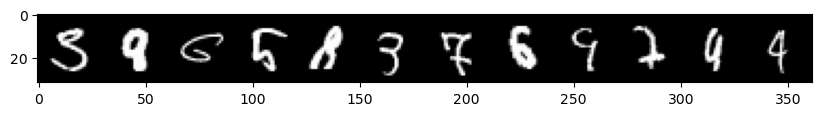

In [148]:
nextrow = next(row)
print("Index:", nextrow)
print("Label:", y_test.index_select(0,torch.tensor(nextrow)).numpy())
print("Guess:", predicted.index_select(0,torch.tensor(nextrow)).numpy())

images = X_test.index_select(0,torch.tensor(nextrow))
im = make_grid(images, nrow=r)
plt.figure(figsize=(10,4))
plt.imshow(np.transpose(im.numpy(), (1, 2, 0)));

## Finished!!!